In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [7]:
dataset1 = pd.read_csv('/content/drive/MyDrive/Deep Learning/DL Exp-1 spreadsheet - Sheet1.csv')
X = dataset1[['Input']].values
Y = dataset1[['Output']].values
print(X)
print(Y)

[[12]
 [18]
 [85]
 [52]
 [12]
 [48]
 [56]
 [47]
 [26]
 [15]
 [48]
 [69]
 [15]
 [24]
 [25]
 [63]
 [95]
 [85]
 [47]
 [78]]
[[74]
 [52]
 [16]
 [58]
 [45]
 [65]
 [63]
 [69]
 [68]
 [62]
 [75]
 [42]
 [53]
 [86]
 [95]
 [41]
 [85]
 [75]
 [36]
 [53]]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [14]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [6]:
dataset1.head()

,Input,Output
0,12,74
1,18,52
2,85,16
3,52,58
4,12,45


In [17]:
# Name: RAMYA R
# Register Number: 212223230169
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        # Include your code here
        self.fc1= nn.Linear(1,8)
        self.fc2= nn.Linear(8,10)
        self.fc3= nn.Linear(10,1)
        self.relu=nn.ReLU()
        self.history = {'loss': []}

  def forward(self,x):
    x=self.relu(self.fc1(x))
    x=self.relu(self.fc2(x))
    x=self.fc3(x)
    return x

In [21]:
# Initialize the Model, Loss Function, and Optimizer
# Write your code here
lig = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.RMSprop(lig.parameters(), lr=0.001)

In [23]:
# Name: RAMYA R
# Register Number: 212223230169
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    # Write your code here
    for epoch in range (epochs):
      optimizer.zero_grad()
      loss=criterion(ai_brain(X_train),y_train)
      loss.backward()
      optimizer.step()

      lig.history['loss'].append(loss.item())
      if epoch % 200 == 0:
          print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')


In [24]:
train_model(lig, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 4254.690430
Epoch [200/2000], Loss: 3989.643555
Epoch [400/2000], Loss: 3541.387695
Epoch [600/2000], Loss: 2900.692871
Epoch [800/2000], Loss: 2142.035645
Epoch [1000/2000], Loss: 1402.191162
Epoch [1200/2000], Loss: 857.861328
Epoch [1400/2000], Loss: 619.492065
Epoch [1600/2000], Loss: 544.838562
Epoch [1800/2000], Loss: 503.544922


In [25]:
with torch.no_grad():
    test_loss = criterion(lig(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 354.181244


In [27]:
loss_df = pd.DataFrame(lig.history)

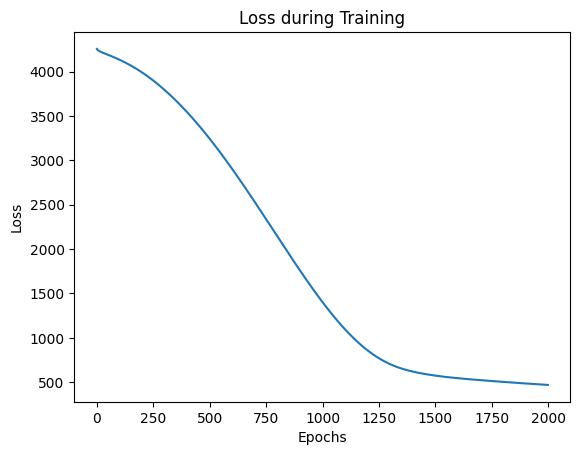

In [31]:
import matplotlib.pyplot as plt
plt.plot(lig.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [34]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = lig(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 226.5189971923828
